<a href="https://colab.research.google.com/github/ankush07das/Digital-Image-Watermarking-using-discrete-wavelet-transform/blob/main/Comparison%20Haar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install pillow
!pip install PyWavelets
import pywt
import numpy as np
from PIL import Image,ImageEnhance
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [4]:
original_image_path = '/content/image.jpeg'  # Update with correct path
watermark_image_path = '/content/watermark_image.jpg'  # Update with correct path
watermarked_image_path = '/content/watermarked_image.png'

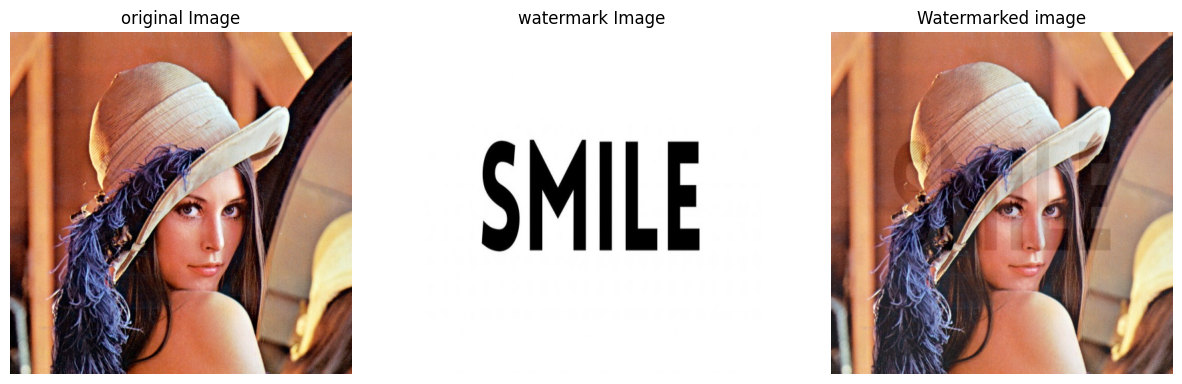

In [11]:
original_image = cv2.imread(original_image_path, cv2.IMREAD_UNCHANGED) # Load original image
watermark_image = cv2.imread(watermark_image_path, cv2.IMREAD_UNCHANGED)  # Load watermark

# Resize watermark to match the original image size
watermark_image = cv2.resize(watermark_image, (original_image.shape[1], original_image.shape[0]))

# Convert to float32 for blending
original = original_image.astype(np.float32)
watermark = watermark_image.astype(np.float32)

# Define opacity level (0 = invisible, 1 = fully visible)
alpha = 0.1  # Adjust as needed

# Apply alpha blending formula
watermarked_image = ((1 - alpha) * original + alpha * watermark).astype(np.uint8)

# Save and display the watermarked image
cv2.imwrite("/content/watermarked_image.png", watermarked_image)

# Convert to RGB for Matplotlib (since OpenCV loads in BGR format)
watermarked_rgb = cv2.cvtColor(watermarked_image, cv2.COLOR_BGR2RGB)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
# Plot all images in a single figure
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Display original image
ax[0].imshow(original_image)
ax[0].set_title("original Image")
ax[0].axis("off")

# Display watermark image
ax[1].imshow(watermark_image)
ax[1].set_title("watermark Image")
ax[1].axis("off")

# Display extracted watermark
ax[2].imshow(watermarked_rgb)
ax[2].set_title("Watermarked image")
ax[2].axis("off")

# Show the final combined output
plt.show()

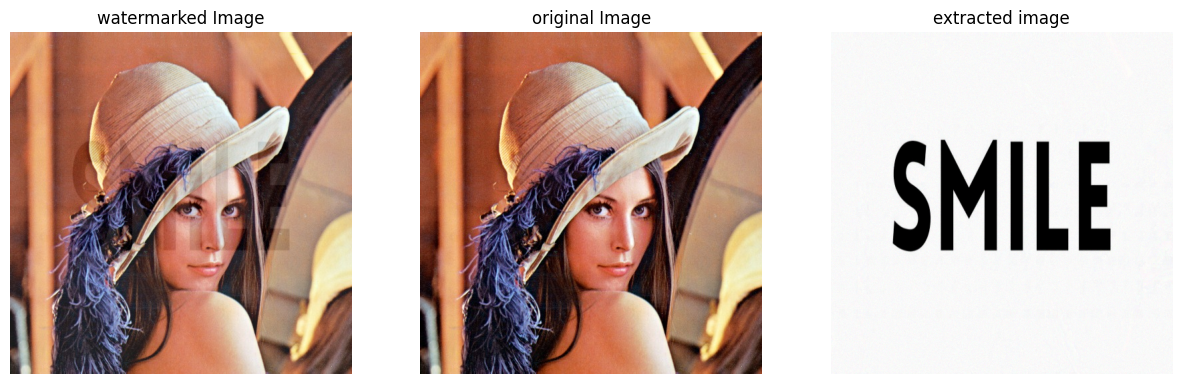

In [6]:
original= cv2.imread(original_image_path, cv2.IMREAD_UNCHANGED).astype(np.float32)
watermarked = cv2.imread(watermarked_image_path, cv2.IMREAD_UNCHANGED).astype(np.float32)

# Define the same opacity level used in watermarking
alpha = 0.1  # Adjust if different opacity was used

# Extract the watermark using the inverse formula
extracted_watermark = (watermarked - (1 - alpha) * original) / (alpha + 1e-6)

# Clip values to ensure they stay in range 0-255
extracted_watermark = np.clip(extracted_watermark, 0, 255).astype(np.uint8)

# Convert to RGB for Matplotlib (since OpenCV loads in BGR format)
extracted_rgb = cv2.cvtColor(extracted_watermark, cv2.COLOR_BGR2RGB)

# Plot all images in a single figure
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Display original image
ax[0].imshow(watermarked_rgb)
ax[0].set_title("watermarked Image")
ax[0].axis("off")

# Display watermark image
ax[1].imshow(original_image)
ax[1].set_title("original Image")
ax[1].axis("off")

# Display extracted watermark
ax[2].imshow(extracted_rgb)
ax[2].set_title("extracted image")
ax[2].axis("off")

# Show the final combined output
plt.show()

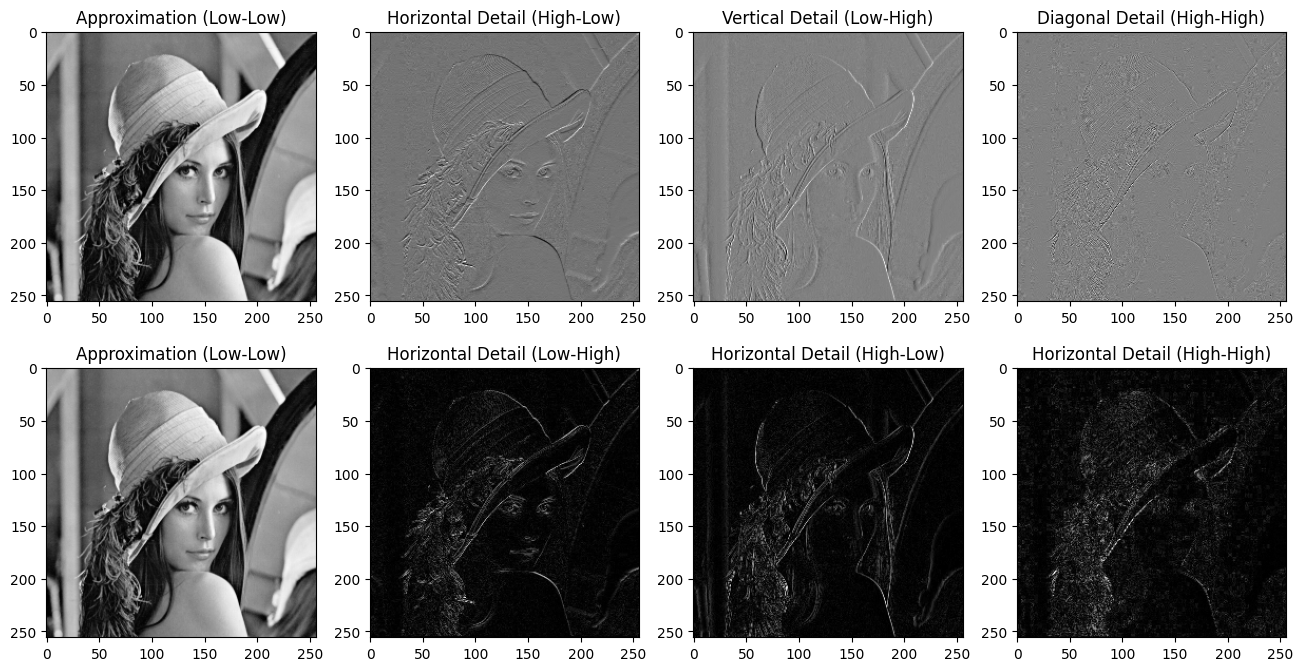

In [8]:
original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)

# Check if the image is loaded properly
if original_image is None:
    print("Error: Could not load the image. Please check the file path.")
else:
    # Perform Single-Level 2D Discrete Wavelet Transform
    coeffs2 = pywt.dwt2(original_image, 'haar')

    # Extract approximation and detail coefficients
    LL, (LH, HL, HH) = coeffs2

# Normalize function to scale values to 0-255 for visualization
def normalize_and_display(subband):
    subband = np.abs(subband)  # Take absolute values (ignore negative signs)
    subband = (subband / np.max(subband)) * 255  # Normalize to 0-255
    subband = np.uint8(subband)
    return subband

# Display the original image and transformed subbands
plt.figure(figsize=(16, 8))

plt.subplot(2, 4, 1)
plt.imshow(LL, cmap='gray')
plt.title('Approximation (Low-Low)')

plt.subplot(2, 4, 2)
plt.imshow(LH, cmap='gray')
plt.title('Horizontal Detail (High-Low)')

plt.subplot(2, 4, 3)
plt.imshow(HL, cmap='gray')
plt.title('Vertical Detail (Low-High)')

plt.subplot(2, 4, 4)
plt.imshow(HH, cmap='gray')
plt.title('Diagonal Detail (High-High)')

plt.subplot(2, 4, 5)
plt.imshow(normalize_and_display(LL), cmap='gray')
plt.title('Approximation (Low-Low)')

plt.subplot(2, 4, 6)
plt.imshow(normalize_and_display(LH), cmap='gray')
plt.title('Horizontal Detail (Low-High)')

plt.subplot(2, 4, 7)
plt.imshow(normalize_and_display(HL), cmap='gray')
plt.title('Horizontal Detail (High-Low)')

plt.subplot(2, 4, 8)
plt.imshow(normalize_and_display(HH), cmap='gray')
plt.title('Horizontal Detail (High-High)')

plt.show()

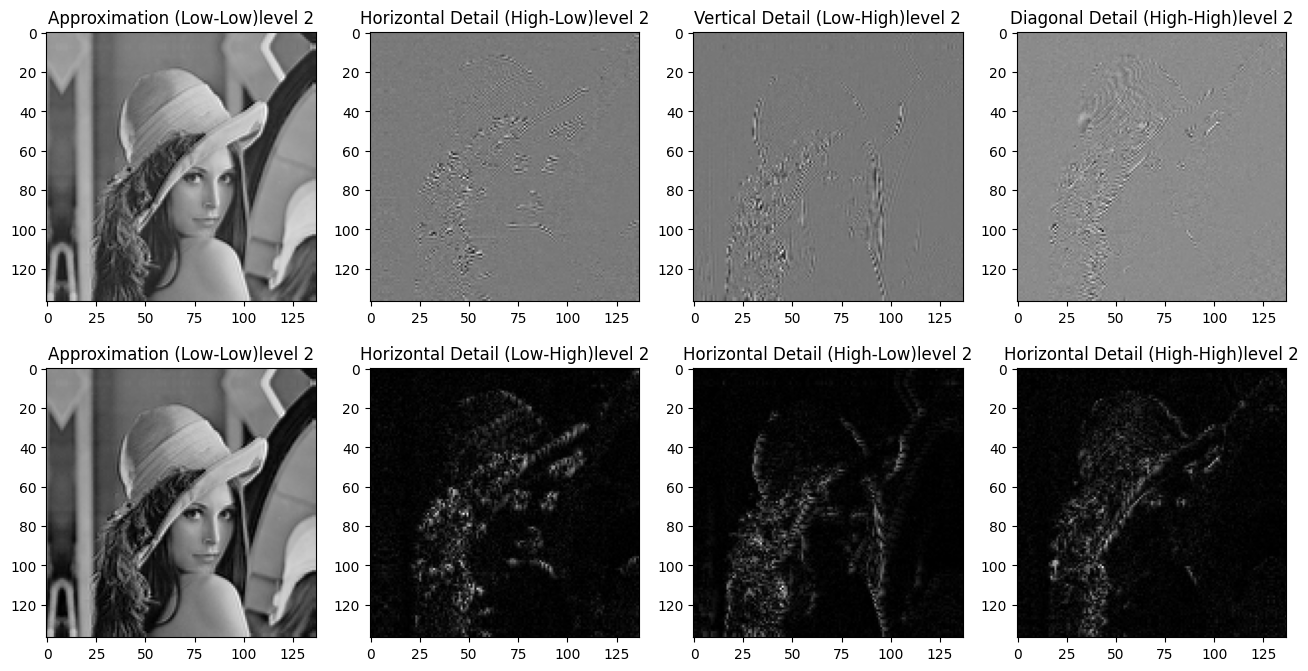

In [9]:
# Load the image in grayscale
original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)

# Check if the image is loaded properly
if original_image is None:
    print("Error: Could not load the image. Please check the file path.")
else:
    # Perform Single-Level 2D Discrete Wavelet Transform
    coeffs2 = pywt.dwt2(original_image, 'haar')

    # Extract approximation and detail coefficients
    LL, (LH, HL, HH) = coeffs2

    # Perform Second-Level DWT on LL using Daubechies (db10)
    coeffs3 = pywt.dwt2(LL, 'db10')
    LL1, (LH1, HL1, HH1) = coeffs3

# Normalize function to scale values to 0-255 for visualization
def normalize_and_display(subband):
    subband = np.abs(subband)  # Take absolute values (ignore negative signs)
    subband = (subband / np.max(subband)) * 255  # Normalize to 0-255
    subband = np.uint8(subband)
    return subband

# Display the original image and transformed subbands
plt.figure(figsize=(16, 8))

plt.subplot(2, 4, 1)
plt.imshow(LL1, cmap='gray')
plt.title('Approximation (Low-Low)level 2')

plt.subplot(2, 4, 2)
plt.imshow(LH1, cmap='gray')
plt.title('Horizontal Detail (High-Low)level 2')

plt.subplot(2, 4, 3)
plt.imshow(HL1, cmap='gray')
plt.title('Vertical Detail (Low-High)level 2')

plt.subplot(2, 4, 4)
plt.imshow(HH1, cmap='gray')
plt.title('Diagonal Detail (High-High)level 2')

plt.subplot(2, 4, 5)
plt.imshow(normalize_and_display(LL1), cmap='gray')
plt.title('Approximation (Low-Low)level 2')

plt.subplot(2, 4, 6)
plt.imshow(normalize_and_display(LH1), cmap='gray')
plt.title('Horizontal Detail (Low-High)level 2')

plt.subplot(2, 4, 7)
plt.imshow(normalize_and_display(HL1), cmap='gray')
plt.title('Horizontal Detail (High-Low)level 2')

plt.subplot(2, 4, 8)
plt.imshow(normalize_and_display(HH1), cmap='gray')
plt.title('Horizontal Detail (High-High)level 2')

plt.show()

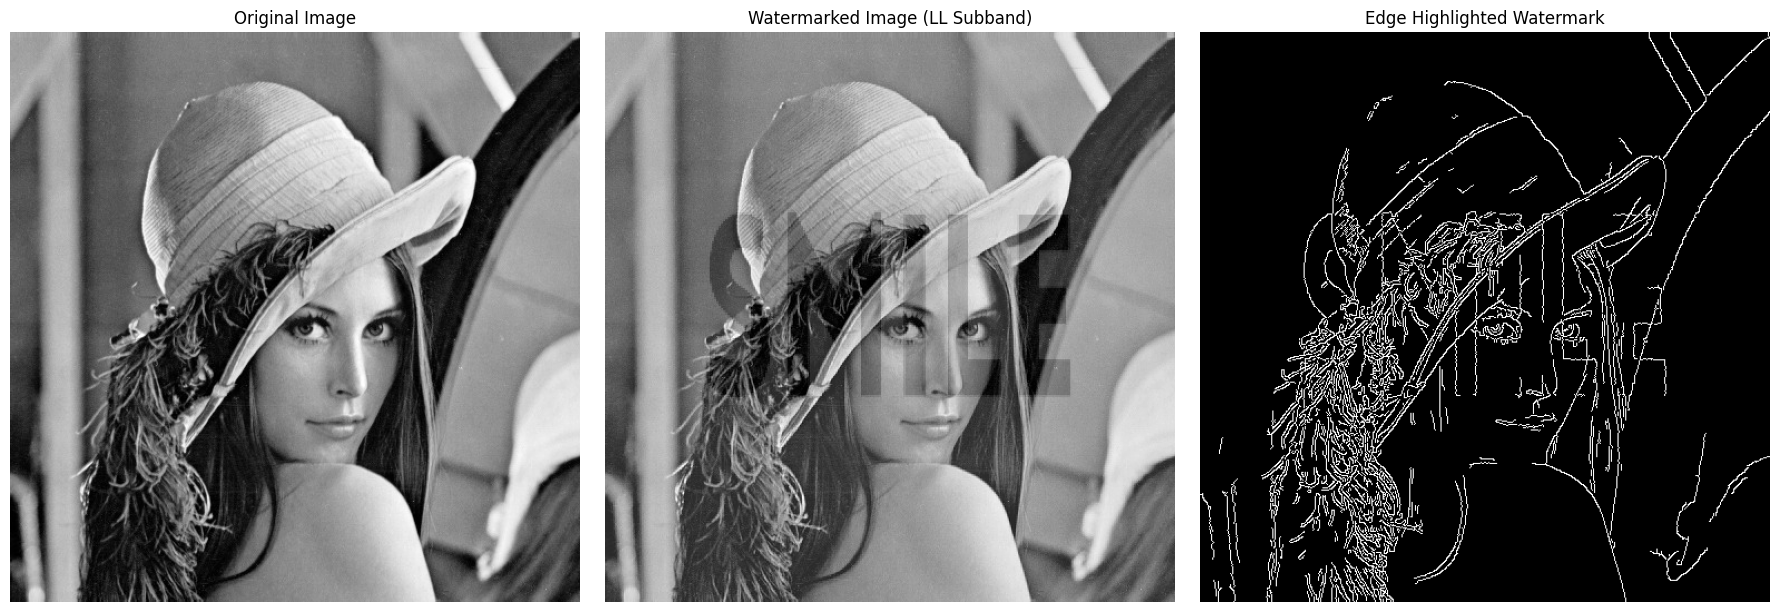

In [18]:


# Load the original image and watermark in grayscale
original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
watermark_image = cv2.imread(watermark_image_path, cv2.IMREAD_GRAYSCALE)

# Check if the image is loaded properly
if original_image is None:
    print("Error: Could not load the image. Please check the file path.")
else:
    # Perform Single-Level 2D Discrete Wavelet Transform
    coeffs2 = pywt.dwt2(original_image, 'haar')

    # Extract approximation and detail coefficients
    LL, (LH, HL, HH) = coeffs2

    # Resize watermark to match the LL subband size
    watermark_resized = cv2.resize(watermark_image, (LL.shape[1], LL.shape[0]))

    # Convert to float32 for blending
    LL_float = LL.astype(np.float32)
    watermark_float = watermark_resized.astype(np.float32)

    # Define opacity level
    alpha = 0.3  # Increased for better visibility

    # Blend watermark with LL subband
    LL_watermarked = ((1 - alpha) * LL_float + alpha * watermark_float).astype(np.float32)

    # Perform inverse DWT to reconstruct the image
    coeffs_watermarked = (LL_watermarked, (LH, HL, HH))
    watermarked_image = pywt.idwt2(coeffs_watermarked, 'haar')
    watermarked_image = np.clip(watermarked_image, 0, 255).astype(np.uint8)

    # Save watermarked image with watermark embedded in LL subband
    cv2.imwrite('/content/LL_watermarked_image.png', watermarked_image)

    # Generate edge-highlighted version (black background + embedded edges)
    edges = cv2.Canny(watermarked_image.astype(np.uint8), 100, 200)
    embedded_edges = np.zeros_like(watermarked_image)
    embedded_edges[edges > 0] = 255

    # Display original image, watermarked image, and edge-highlighted version
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(original_image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(watermarked_image, cmap='gray')
    plt.title('Watermarked Image (LL Subband)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(embedded_edges, cmap='gray')
    plt.title('Edge Highlighted Watermark')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.11/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)
/usr/local/lib/python3.11/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


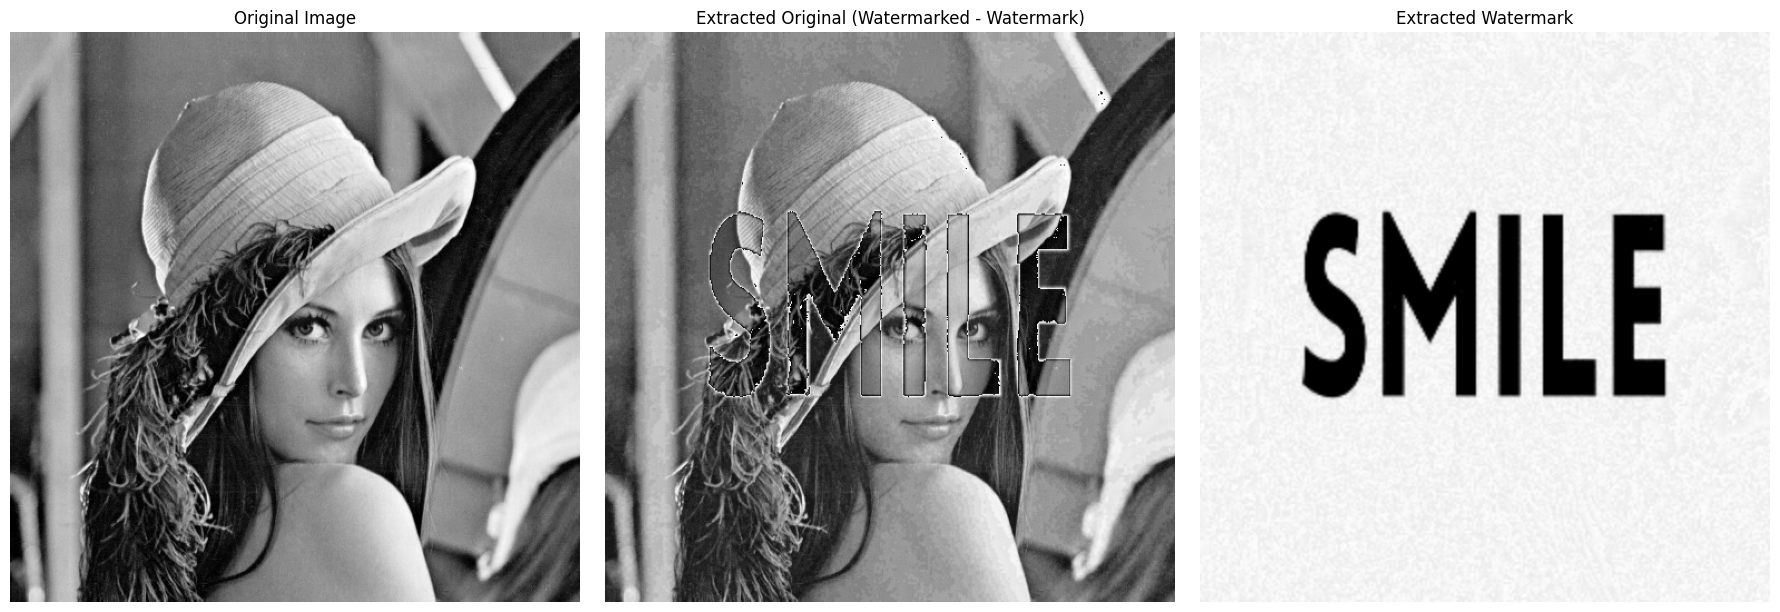


========= IMAGE QUALITY REPORT =========

[Original Image]
  MSE:  0.00
  PSNR: inf dB

[Extracted Original (Watermarked - Watermark)]
  MSE:  577.76
  PSNR: 20.51 dB

[Original Watermark]
  MSE:  0.00
  PSNR: inf dB

[Extracted Watermark]
  MSE:  178.23
  PSNR: 25.62 dB


In [43]:
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from sklearn.metrics import mean_squared_error

# Load paths
original_image_path = '/content/image.jpeg'
watermark_image_path = '/content/watermark_image.jpg'

# Load images in grayscale
original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
watermark_image = cv2.imread(watermark_image_path, cv2.IMREAD_GRAYSCALE)

# 1st Level DWT on original image
coeffs2 = pywt.dwt2(original_image, 'haar')
LL, (LH, HL, HH) = coeffs2

# Resize watermark to match LL size
watermark_resized = cv2.resize(watermark_image, (LL.shape[1], LL.shape[0]))

# Embed watermark into LL
alpha = 0.1
LL_embedded = ((1 - alpha) * LL + alpha * watermark_resized).astype(np.float32)

# Perform inverse DWT with modified LL to get the watermarked image
watermarked_image = pywt.idwt2((LL_embedded, (LH, HL, HH)), 'haar')
watermarked_image = np.clip(watermarked_image, 0, 255).astype(np.uint8)

# ======= Extraction Process =======
# DWT on watermarked image
coeffs2_wm = pywt.dwt2(watermarked_image, 'haar')
LL_wm, _ = coeffs2_wm

# Extract watermark by subtracting original LL from watermarked LL
extracted_watermark = ((LL_wm - (1 - alpha) * LL) / alpha)
extracted_watermark = np.clip(extracted_watermark, 0, 255).astype(np.uint8)

# Resize extracted watermark to match watermarked image size
extracted_watermark_resized = cv2.resize(extracted_watermark, watermarked_image.shape[::-1])

# Remove watermark from watermarked image to get the original image
extracted_original_image = watermarked_image - extracted_watermark_resized
extracted_original_image = np.clip(extracted_original_image, 0, 255).astype(np.uint8)

# Resize for comparison
resized_watermark = cv2.resize(watermark_image, extracted_watermark_resized.shape[::-1])
resized_original = cv2.resize(original_image, watermarked_image.shape[::-1])

# ========== METRICS ==========
# 1. Original image
mse_ori = mean_squared_error(original_image.flatten(), original_image.flatten())
psnr_ori = psnr(original_image, original_image)

# 2. Extracted original (watermarked image - watermark)
mse_extracted_ori = mean_squared_error(original_image.flatten(), extracted_original_image.flatten())
psnr_extracted_ori = psnr(original_image, extracted_original_image)

# 3. Original watermark
mse_wm = mean_squared_error(resized_watermark.flatten(), resized_watermark.flatten())
psnr_wm = psnr(resized_watermark, resized_watermark)

# 4. Extracted watermark
mse_extracted_wm = mean_squared_error(resized_watermark.flatten(), extracted_watermark_resized.flatten())
psnr_extracted_wm = psnr(resized_watermark, extracted_watermark_resized)

# ========== DISPLAY ==========
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(extracted_original_image, cmap='gray')
plt.title("Extracted Original (Watermarked - Watermark)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(extracted_watermark_resized, cmap='gray')
plt.title("Extracted Watermark")
plt.axis('off')

plt.tight_layout()
plt.show()

# ========== PRINT QUALITY REPORT ==========
print("\n========= IMAGE QUALITY REPORT =========")

print("\n[Original Image]")
print(f"  MSE:  {mse_ori:.2f}")
print(f"  PSNR: {psnr_ori:.2f} dB")

print("\n[Extracted Original (Watermarked - Watermark)]")
print(f"  MSE:  {mse_extracted_ori:.2f}")
print(f"  PSNR: {psnr_extracted_ori:.2f} dB")

print("\n[Original Watermark]")
print(f"  MSE:  {mse_wm:.2f}")
print(f"  PSNR: {psnr_wm:.2f} dB")

print("\n[Extracted Watermark]")
print(f"  MSE:  {mse_extracted_wm:.2f}")
print(f"  PSNR: {psnr_extracted_wm:.2f} dB")


Original Image:

MSE: 0.00: This indicates that there is no difference between the original image and itself (which is expected, as you are comparing it to itself).

PSNR: inf dB: The PSNR value is infinity, which signifies that the image is perfectly identical to itself, and there is no noise or distortion.

Extracted Original (Watermarked - Watermark):

MSE: 577.76: The Mean Squared Error (MSE) is a measure of the difference between the original image and the extracted original image (after subtracting the watermark). A lower MSE indicates higher similarity. This value is relatively high, meaning the extracted image still has significant differences from the original.

PSNR: 20.51 dB: The Peak Signal-to-Noise Ratio (PSNR) is a metric that measures the quality of the reconstructed image. In general, a PSNR value above 30 dB is considered high quality. A PSNR of 20.51 dB is relatively low, indicating that the extracted image (watermarked image minus the watermark) is of moderate quality, and the watermark removal is not perfect.

Original Watermark:

MSE: 0.00: Again, as with the original image, there is no difference between the original watermark and itself.

PSNR: inf dB: Perfect similarity with itself, no noise or distortion.

Extracted Watermark:

MSE: 178.23: The Mean Squared Error here indicates the difference between the original watermark and the extracted watermark. A higher MSE means the extracted watermark is different from the original watermark.

PSNR: 25.62 dB: This is a fairly decent value for watermark extraction. A PSNR of 25.62 dB indicates that the extracted watermark is reasonably close to the original, but there is some degradation due to the embedding process or the attack during extraction.

/usr/local/lib/python3.11/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)
/usr/local/lib/python3.11/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


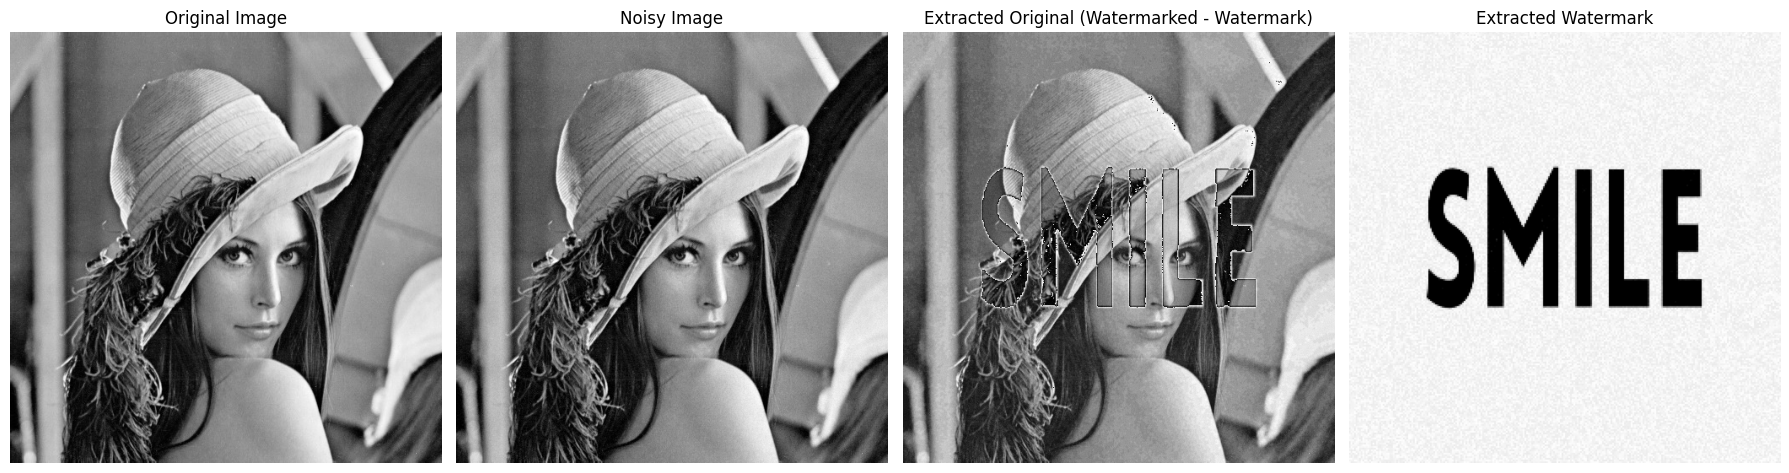


========= IMAGE QUALITY REPORT =========

[Original Image]
  MSE:  0.00
  PSNR: inf dB

[Noisy Image]
  MSE:  10.27
  PSNR: 38.01 dB

[Extracted Original (Watermarked - Watermark)]
  MSE:  600.39
  PSNR: 20.35 dB

[Original Watermark]
  MSE:  0.00
  PSNR: inf dB

[Extracted Watermark]
  MSE:  125.73
  PSNR: 27.14 dB


In [49]:
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from sklearn.metrics import mean_squared_error

# Load paths
original_image_path = '/content/image.jpeg'
watermark_image_path = '/content/watermark_image.jpg'

# Load images in grayscale
original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
watermark_image = cv2.imread(watermark_image_path, cv2.IMREAD_GRAYSCALE)

# Function to add Gaussian noise to an image
def add_gaussian_noise(image, mean=0, var=10):
    sigma = var**0.5
    gaussian_noise = np.random.normal(mean, sigma, image.shape)
    noisy_image = np.clip(image + gaussian_noise, 0, 255).astype(np.uint8)
    return noisy_image

# Add Gaussian noise to the original image
noisy_image = add_gaussian_noise(original_image)

# 1st Level DWT on noisy image
coeffs2 = pywt.dwt2(noisy_image, 'haar')
LL, (LH, HL, HH) = coeffs2

# Resize watermark to match LL size
watermark_resized = cv2.resize(watermark_image, (LL.shape[1], LL.shape[0]))

# Embed watermark into LL with a lower alpha value to reduce visibility
alpha = 0.1  # Lower alpha value to reduce watermark strength
LL_embedded = ((1 - alpha) * LL + alpha * watermark_resized).astype(np.float32)

# Perform inverse DWT with modified LL
watermarked_image = pywt.idwt2((LL_embedded, (LH, HL, HH)), 'haar')
watermarked_image = np.clip(watermarked_image, 0, 255).astype(np.uint8)

# ======= Extraction Process =======
# DWT on watermarked image
coeffs2_wm = pywt.dwt2(watermarked_image, 'haar')
LL_wm, _ = coeffs2_wm

# Extract watermark from LL
extracted_watermark = ((LL_wm - (1 - alpha) * LL) / alpha)
extracted_watermark = np.clip(extracted_watermark, 0, 255).astype(np.uint8)

# Extract original image (watermarked image - watermark)
extracted_original_image = watermarked_image - cv2.resize(extracted_watermark, watermarked_image.shape[::-1])
extracted_original_image = np.clip(extracted_original_image, 0, 255).astype(np.uint8)

# Resize for comparison
resized_watermark = cv2.resize(watermark_image, extracted_watermark.shape[::-1])
resized_original = cv2.resize(original_image, watermarked_image.shape[::-1])

# ========== METRICS ==========

# 1. Original image
mse_ori = mean_squared_error(original_image.flatten(), original_image.flatten())
psnr_ori = psnr(original_image, original_image)

# 2. Noisy image
mse_noisy = mean_squared_error(original_image.flatten(), noisy_image.flatten())
psnr_noisy = psnr(original_image, noisy_image)

# 3. Extracted original (watermarked image - watermark)
mse_extracted_ori = mean_squared_error(original_image.flatten(), extracted_original_image.flatten())
psnr_extracted_ori = psnr(original_image, extracted_original_image)

# 4. Original watermark
mse_wm = mean_squared_error(resized_watermark.flatten(), resized_watermark.flatten())
psnr_wm = psnr(resized_watermark, resized_watermark)

# 5. Extracted watermark
mse_extracted_wm = mean_squared_error(resized_watermark.flatten(), extracted_watermark.flatten())
psnr_extracted_wm = psnr(resized_watermark, extracted_watermark)

# ========== DISPLAY ==========

plt.figure(figsize=(18, 8))

plt.subplot(1, 4, 1)
plt.imshow(original_image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title("Noisy Image")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(extracted_original_image, cmap='gray')
plt.title("Extracted Original (Watermarked - Watermark)")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(extracted_watermark, cmap='gray')
plt.title("Extracted Watermark")
plt.axis('off')

plt.tight_layout()
plt.show()

# ========== PRINT QUALITY REPORT ==========

print("\n========= IMAGE QUALITY REPORT =========")

print("\n[Original Image]")
print(f"  MSE:  {mse_ori:.2f}")
print(f"  PSNR: {psnr_ori:.2f} dB")

print("\n[Noisy Image]")
print(f"  MSE:  {mse_noisy:.2f}")
print(f"  PSNR: {psnr_noisy:.2f} dB")

print("\n[Extracted Original (Watermarked - Watermark)]")
print(f"  MSE:  {mse_extracted_ori:.2f}")
print(f"  PSNR: {psnr_extracted_ori:.2f} dB")

print("\n[Original Watermark]")
print(f"  MSE:  {mse_wm:.2f}")
print(f"  PSNR: {psnr_wm:.2f} dB")

print("\n[Extracted Watermark]")
print(f"  MSE:  {mse_extracted_wm:.2f}")
print(f"  PSNR: {psnr_extracted_wm:.2f} dB")
